In [1]:
import os
import pandas as pd
# use polars when using very large dataframes as polars is faster than pandas
import polars as pl

import seaborn as sns

# use pickle to save and load data objects (when saving a df using pickle, you save more information)
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from itertools import product


# With the ic() method you can print something that is between the brackets and automatically also print its name
from icecream import ic


In [2]:
with open('../Data/data/dc-scoped-df.pkl', 'rb') as pickle_file:
    dc_scoped_df = pickle.load(pickle_file)

df_70pcnt_scoped = dc_scoped_df['df_70pcnt_scoped']
df_orig = dc_scoped_df['df_pd_pandas']
df_50pcnt_scoped = dc_scoped_df['df_50pcnt_scoped']
df_top_10  = dc_scoped_df['df_top_10']


## Group by Store and make a plot showing contribution to total sales

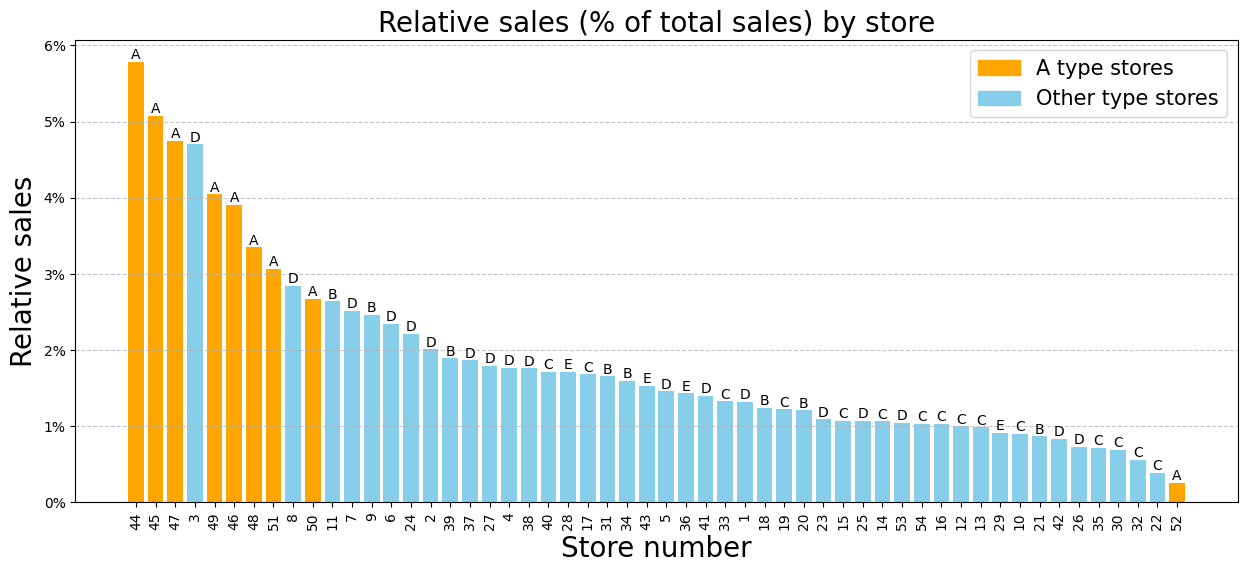

In [3]:
sales_by_store = df_orig.groupby('store_nbr').agg({
    'unit_sales': 'sum',  # Sum the unit sales
    'type': 'first',  # Keep the first 'type' entry for each store_nbr
    'city': 'first'
}).reset_index()

# Get city info for each store
store_city = df_orig[['store_nbr', 'city']].drop_duplicates()

# Sort by 'unit_sales' descending
sales_by_store_sorted = sales_by_store.sort_values(by='unit_sales', ascending=False)

# Convert 'store_nbr' to categorical with explicit ordering
sales_by_store_sorted['store_nbr'] = pd.Categorical(
    sales_by_store_sorted['store_nbr'], categories=sales_by_store_sorted['store_nbr'], ordered=True)

# Calculate Relative sales
total_unit_sales = sales_by_store_sorted['unit_sales'].sum()
sales_by_store_sorted['relative sales'] = 100*sales_by_store_sorted['unit_sales'] / total_unit_sales

# Strip spaces from column names
sales_by_store_sorted.columns = sales_by_store_sorted.columns.str.strip()

# **DO NOT REASSIGN sales_by_store_sorted HERE!** Keep the processed version

# Set 'store_nbr' as the index to preserve order
sales_by_store_sorted.set_index('store_nbr', inplace=True)

# Example: sales_by_store_sorted contains 'store_nbr', 'unit_sales', and 'city'
highlight_type = 'A'
highlight_color = 'orange'
default_color = 'skyblue'


plt.figure(figsize=(15, 6))

# Create legend manually
A_type_patch = mpatches.Patch(color=highlight_color, label="A type stores")
other_cities_patch = mpatches.Patch(color=default_color, label="Other type stores")
plt.legend(handles=[A_type_patch, other_cities_patch], loc="upper right", fontsize=15)

# Create a color list for each bar
bar_colors = sales_by_store_sorted['type'].apply(lambda c: highlight_color if c == highlight_type else default_color)

# **Use column name instead of index for clarity**
plt.bar(sales_by_store_sorted.index.astype(str), sales_by_store_sorted['relative sales'], color=bar_colors)

# Add labels from the 'type' column
for idx, value in enumerate(sales_by_store_sorted['relative sales']):
    plt.text(
        sales_by_store_sorted.index.astype(str)[idx],  # X position
        value,  # Y position
        sales_by_store_sorted['type'].iloc[idx],  # Label text
        ha='center', va='bottom')  # Centering and positioning
    
# Improve readability
plt.xticks(rotation=90)
plt.xlabel("Store number", fontsize=20)
plt.ylabel("Relative sales", fontsize=20)
plt.title("Relative sales (% of total sales) by store", fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Format y-axis labels to show percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.show()

## print all perishable family values

In [4]:
# Filtering for perishable items (perishable == 1)
perishable_families = df_orig[df_orig['perishable'] == 1]['family'].unique()

# Printing the list of perishable family values
print("Perishable Family Values:")
print(perishable_families)

Perishable Family Values:
['BREAD/BAKERY', 'DELI', 'DAIRY', 'EGGS', 'POULTRY', 'PREPARED FOODS', 'MEATS', 'SEAFOOD', 'PRODUCE']
Categories (33, object): ['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', ..., 'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES', 'SEAFOOD']


## Group by family and sum unit_sales

C:\Users\jasmi\AppData\Local\Temp\ipykernel_27016\949762709.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_family = df_orig.groupby('family').agg({


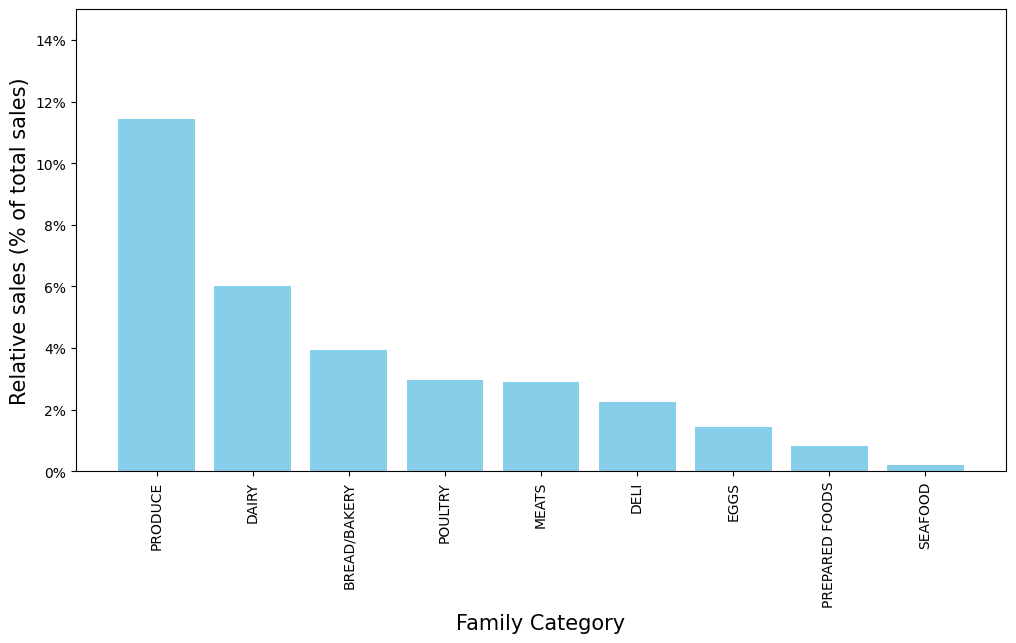

In [5]:
# Group by family and sum the sales
sales_by_family = df_orig.groupby('family').agg({
    'unit_sales': 'sum',  # Sum the unit sales
    'perishable': 'first',  # Keep the first 'perishable' entry for each store_nbr
    }).reset_index()


# Sort by 'unit_sales' descending
sales_by_family_sorted = sales_by_family.sort_values(by='unit_sales', ascending=False)
total_unit_sales = sales_by_family_sorted['unit_sales'].sum()

sales_by_family_sorted['proportion to total sales'] =100*sales_by_family_sorted['unit_sales']/total_unit_sales

# Define colors
# default_color = 'skyblue'
# highlight_color = 'red'
highlight_color = 'skyblue'

# Define the labels to highlight
highlight_labels = ['BREAD/BAKERY', 'DELI', 'DAIRY', 'EGGS', 'PREPARED FOODS', 'SEAFOOD', 'MEATS', 'POULTRY', 'PRODUCE']

# Assign colors based on whether 'family' is in highlight_labels
bar_colors = [highlight_color if family in highlight_labels else default_color for family in sales_by_family_sorted['family']]

sales_by_family_sorted = sales_by_family_sorted[sales_by_family_sorted['perishable']== 1]

plt.figure(figsize=(12, 6))
plt.bar(sales_by_family_sorted['family'], sales_by_family_sorted['proportion to total sales'], color=bar_colors)

# Improve readability
plt.xticks(rotation=90)  # Rotate family labels for better visibility

# Modify label colors selectively
plt.xlabel("Family Category", fontsize=15)
plt.ylim(0, 15)
plt.ylabel("Relative sales (% of total sales)", fontsize=15)

# Format y-axis labels to show percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# **Add a legend to explain colors**
# import matplotlib.patches as mpatches
# highlight_patch = mpatches.Patch(color=highlight_color, label="Perishables")
# other_patch = mpatches.Patch(color=default_color, label="Non perishables")
# plt.legend(handles=[highlight_patch, other_patch], loc="upper right")

# Show the plot
plt.show()

## Create a new date column including the days

In [6]:
df_orig['month'] = df_orig['month'].astype(str)
df_orig['date'] = pd.to_datetime(df_orig['month']) + pd.to_timedelta(df_orig['day'] - 1, unit='d')

## Make a lineplot for produce in function of time and on a weekly basis

C:\Users\jasmi\AppData\Local\Temp\ipykernel_27016\2834182538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_by_family_df = df_orig.groupby(['family', 'date'])['unit_sales'].sum().reset_index()
C:\Users\jasmi\AppData\Local\Temp\ipykernel_27016\2834182538.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_df = grouped_by_family_df.groupby(['family', pd.Grouper(key='date', freq='W')]).sum().reset_index()
c:\Users\jasmi\Documents\2025_Data_analyse\2025_03_Group_project_Supermarket\.venv\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be r

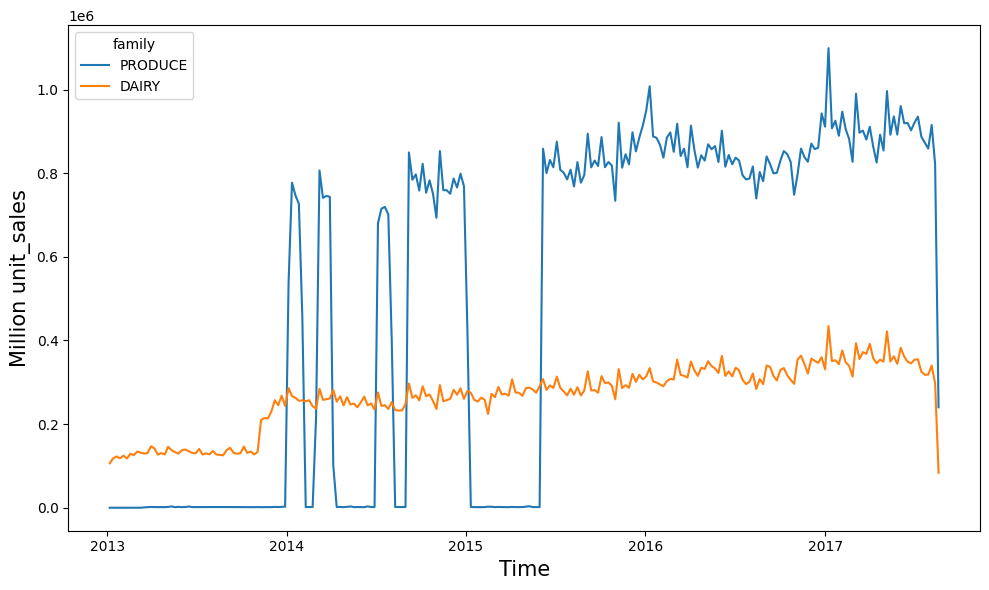

In [7]:
grouped_by_family_df = df_orig.groupby(['family', 'date'])['unit_sales'].sum().reset_index()

weekly_df = grouped_by_family_df.groupby(['family', pd.Grouper(key='date', freq='W')]).sum().reset_index()

top2_df = weekly_df[weekly_df['family'].isin(['PRODUCE','DAIRY'])]
top5_df = weekly_df[weekly_df['family'].isin(['PRODUCE','DAIRY', 'BREAD/BAKERY','POULTRY', 'MEATS'])]
top6_df = weekly_df[weekly_df['family'].isin(['CLEANING', 'DAIRY', 'BREAD/BAKERY'])]
top10_df = weekly_df[weekly_df['family'].isin(['POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'])]
top13_df = weekly_df[weekly_df['family'].isin(['EGGS', 'FROZEN FOODS', 'HOME CARE'])]
top16_df = weekly_df[weekly_df['family'].isin(['PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'])]

 
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.ylabel("Million unit_sales", fontsize=15)
plt.xlabel("Time", fontsize=15)
sns.lineplot(data=top2_df, x='date', y='unit_sales', hue='family', hue_order=['PRODUCE','DAIRY'], ax=ax1)

#fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 12))
#sns.lineplot(data=top6_df, x='date', y='unit_sales', hue='family', hue_order=['CLEANING', 'DAIRY', 'BREAD/BAKERY'], ax=ax2)
#ax2.set_title('Subtop Families (#4-6)')

#sns.lineplot(data=top10_df, x='date', y='unit_sales', hue='family', hue_order=['POULTRY', 'MEATS', 'PERSONAL CARE', 'DELI'], ax=ax3)
#ax3.set_title('Subtop Families (#7-10)')

#sns.lineplot(data=top13_df, x='date', y='unit_sales', hue='family', hue_order=['EGGS', 'FROZEN FOODS', 'HOME CARE'], ax=ax4)
#ax3.set_title('Subtop Families (#11-13)')

#sns.lineplot(data=top16_df, x='date', y='unit_sales', hue='family', hue_order=['PREPARED FOODS', 'LIQUOR,WINE,BEER', 'SEAFOOD'], ax=ax5)
#ax3.set_title('Subtop Families (#14-16)')

plt.tight_layout()
plt.show()
 